# Solar energy analysis for decision Aiding
### This database contains information on several urban solar installation. 


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('solar_energy_worldwide.csv', header=0)
df.head()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   City                           48 non-null     object 
 1   Country                        48 non-null     object 
 2   Latitude                       48 non-null     float64
 3   Longitude                      48 non-null     float64
 4   Annual_Sunlight_Hours          48 non-null     int64  
 5   Daily_Peak_Sun_Hours           48 non-null     float64
 6   GHI_kWh_per_m2                 48 non-null     float64
 7   Electricity_Price_USD_per_kWh  48 non-null     float64
 8   Solar_Installations_Count      48 non-null     int64  
 9   Avg_System_Cost_USD            48 non-null     int64  
 10  Avg_Annual_Production_kWh      48 non-null     int64  
 11  Estimated_Annual_Savings_USD   48 non-null     float64
 12  Payback_Period_Years           48 non-null     float

## Beginner-Friendly Questions
1. Highest and lowest annual sunlight hours by city/country.


In [12]:
#Answer 1:
countries = df['Country'].unique()
cities = df['City'].unique()
data_list = []
#print(f'Countries: {countries}')
for country in countries:
    country_data= df[df['Country']==country]
    maxsun=country_data['Annual_Sunlight_Hours'].max()
    minsun=country_data['Annual_Sunlight_Hours'].min()
    data_list.append({'Country':country,'Max_Annual_Sunlight_Hours':maxsun,'Min_Annual_Sunlight_Hours':minsun})
sunlightmaxmin = pd.DataFrame(data_list)
sunlightmaxmin.head()

,Country,Max_Annual_Sunlight_Hours,Min_Annual_Sunlight_Hours
0,United States,3800,2300
1,Germany,1750,1650
2,United Kingdom,1500,1450
3,France,2100,1750
4,Italy,2500,2000


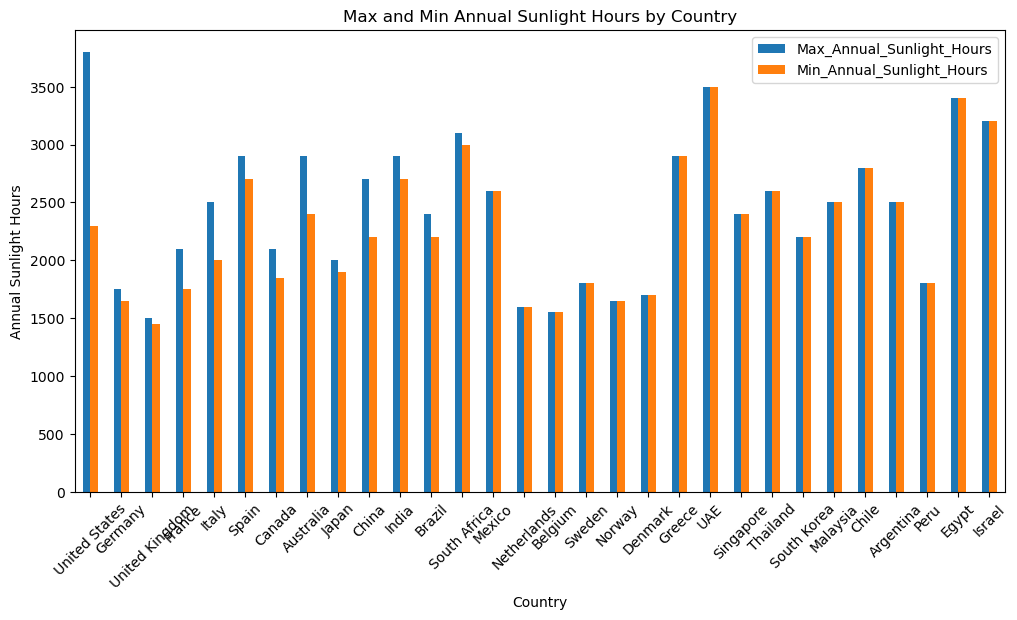

In [13]:
import matplotlib.pyplot as plt
#Now we make a bar plot to visualize the max and min annual sunlight hours for each country
sunlightmaxmin.set_index('Country', inplace=True)
sunlightmaxmin.plot(kind='bar', figsize=(12, 6))
plt.title('Max and Min Annual Sunlight Hours by Country')
plt.ylabel('Annual Sunlight Hours')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.legend()
plt.show()

2. Average GHI values by region.


In [16]:
#Answer 2:
regions= df['Region'].unique()
mylist=[]
for reigion in regions:
    region_data=df[df['Region']==reigion]
    Average_GHI= region_data["GHI_kWh_per_m2"].mean()
    #print(f'Region: {reigion} Average GHI= {Average_GHI}')
    mylist.append({'Region':reigion,'Average_GHI_kWh_per_m2':Average_GHI})
averageghi=pd.DataFrame(mylist)
print(averageghi)

          Region  Average_GHI_kWh_per_m2
0  North America                4.825000
1         Europe                3.687500
2        Oceania                5.066667
3           Asia                4.791667
4  South America                4.800000
5         Africa                5.766667
6    Middle East                5.900000


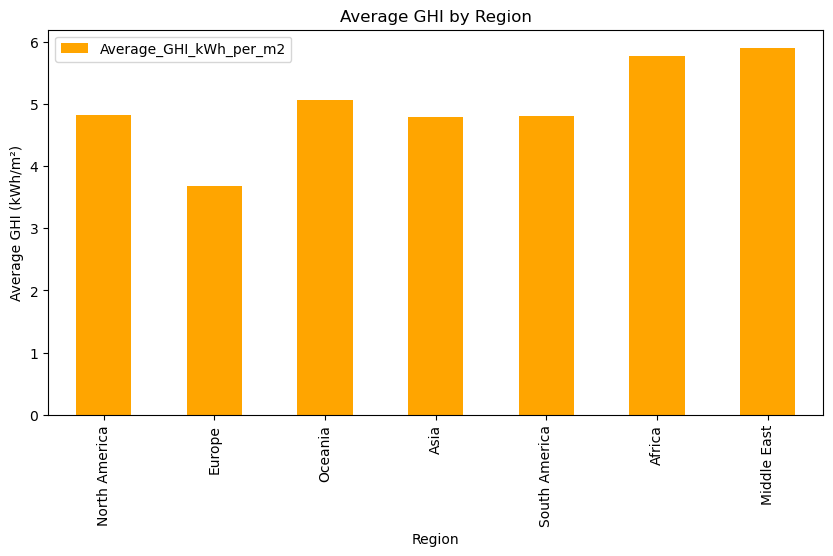

In [17]:
averageghi.set_index('Region', inplace=True)
averageghi.plot(kind='bar', figsize=(10, 5), color='orange')
plt.title('Average GHI by Region')
plt.ylabel('Average GHI (kWh/m²)')
plt.show()

3. Distribution of electricity prices.


In [25]:
df['Electricity_Price_USD_per_kWh'].describe()

count    4.800000e+01
mean     1.500000e-01
std      1.402465e-16
min      1.500000e-01
25%      1.500000e-01
50%      1.500000e-01
75%      1.500000e-01
max      1.500000e-01
Name: Electricity_Price_USD_per_kWh, dtype: float64

In [ ]:
#we cannot create a distribuition because all the prices are the same

4. Cities with the highest solar viability score

In [32]:
solarvis=df.sort_values(by='Solar_Viability_Score', ascending=False)
print(solarvis[['City','Solar_Viability_Score']].head(10))

            City  Solar_Viability_Score
3        Phoenix                     73
38         Dubai                     70
46         Cairo                     68
47      Tel Aviv                     67
1    Los Angeles                     67
29  Johannesburg                     66
30     Cape Town                     65
24         Delhi                     64
2          Miami                     63
43      Santiago                     63


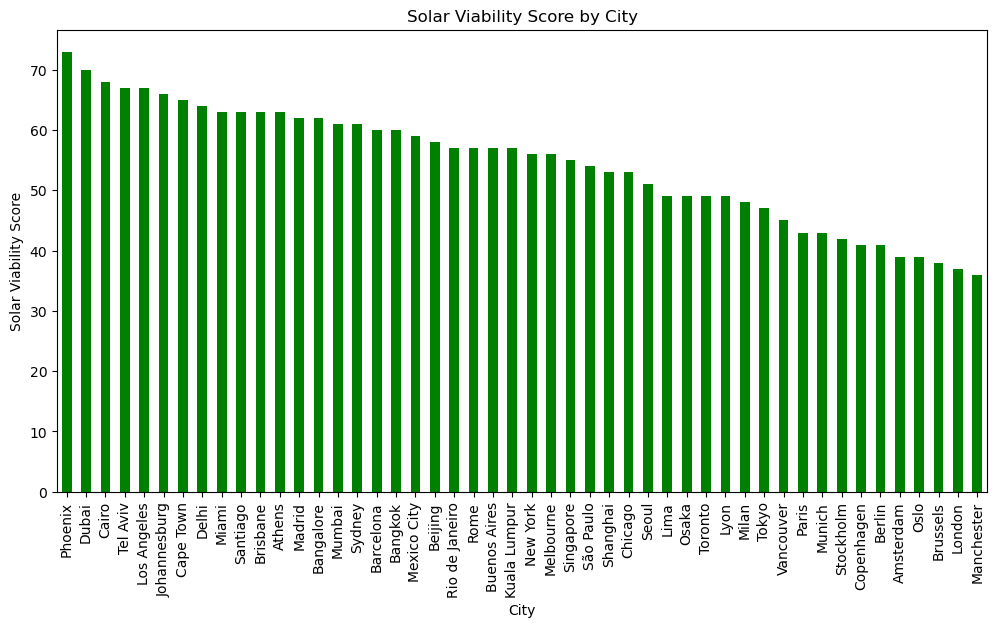

In [33]:
#Barchart of solar viability score of all the cities
solarvis.set_index('City', inplace=True)
solarvis['Solar_Viability_Score'].plot(kind='bar', figsize=(12, 6), color='green')
plt.title('Solar Viability Score by City')
plt.ylabel('Solar Viability Score')
plt.xlabel('City')
plt.show()

## Intermediate Questions
6. Compare annual production across regions.


In [48]:
listm=[]
for region in regions:
    region_data=df[df['Region']==region]
    mean_sc= region_data['Avg_Annual_Production_kWh'].mean()
    max_sc= region_data['Avg_Annual_Production_kWh'].max()
    min_sc= region_data['Avg_Annual_Production_kWh'].min()
    listm.append({'Region':region,'Mean annual production':mean_sc,'Max annual production':max_sc,'Min annual production':min_sc})

systemcost=pd.DataFrame(listm)
systemcost.head(10)

,Region,Mean annual production,Max annual production,Min annual production
0,North America,12009.375,17100,8325
1,Europe,8859.375,13050,6525
2,Oceania,12150.000,13050,10800
3,Asia,11400.000,15750,8550
4,South America,10530.000,12600,8100
5,Africa,14250.000,15300,13500
6,Middle East,14400.000,14400,14400


Or we can generate a boxplot

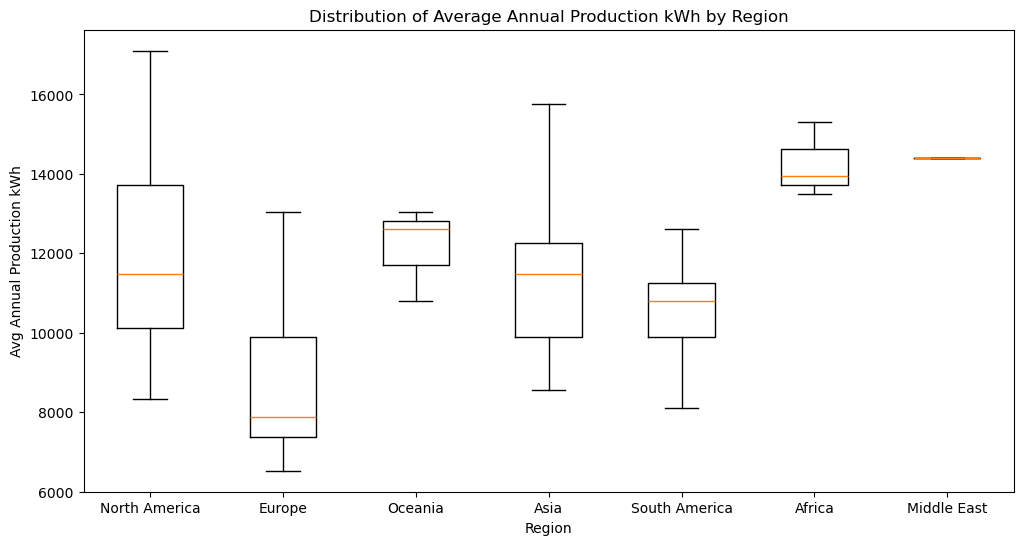

In [47]:
#We generate a boxplot by region to visualize the distribution of average annual production kWh
lists=[]
for region in regions:
    region_data=df[df['Region']==region]
    lists.append(region_data['Avg_Annual_Production_kWh'])
pd.DataFrame(lists, index=regions)
plt.figure(figsize=(12, 6))
plt.boxplot(lists, labels=regions)
plt.title('Distribution of Average Annual Production kWh by Region')
plt.ylabel('Avg Annual Production kWh')
plt.xlabel('Region')
plt.show()

7. Identify cities with the highest production per sunlight hour.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   City                           48 non-null     object  
 1   Country                        48 non-null     object  
 2   Latitude                       48 non-null     float64 
 3   Longitude                      48 non-null     float64 
 4   Annual_Sunlight_Hours          48 non-null     int64   
 5   Daily_Peak_Sun_Hours           48 non-null     float64 
 6   GHI_kWh_per_m2                 48 non-null     float64 
 7   Electricity_Price_USD_per_kWh  48 non-null     float64 
 8   Solar_Installations_Count      48 non-null     int64   
 9   Avg_System_Cost_USD            48 non-null     int64   
 10  Avg_Annual_Production_kWh      48 non-null     int64   
 11  Estimated_Annual_Savings_USD   48 non-null     float64 
 12  Payback_Period_Years           48 non-

In [60]:
#answer 7
df['electricity/sunlight_hour']=df['Avg_Annual_Production_kWh']/(365*df['Daily_Peak_Sun_Hours'])
#sorted_1=df.sort_values(by='electricity/sunlight_hour', ascending=False)
#print(sorted_1[['City','electricity/sunlight_hour']])
print(df[['City','electricity/sunlight_hour']].sort_values(by='electricity/sunlight_hour', ascending=False).head(100))

              City  electricity/sunlight_hour
33        Brussels                   4.549902
0         New York                   4.532635
11            Rome                   4.532635
44    Buenos Aires                   4.532635
42    Kuala Lumpur                   4.532635
45            Lima                   4.528935
34       Stockholm                   4.528935
37          Athens                   4.525750
19        Brisbane                   4.525750
13          Madrid                   4.525750
24           Delhi                   4.525750
41           Seoul                   4.520548
5           Berlin                   4.520548
27       São Paulo                   4.520548
35            Oslo                   4.520548
23        Shanghai                   4.520548
40         Bangkok                   4.514760
31     Mexico City                   4.514760
2            Miami                   4.510525
7           London                   4.510525
30       Cape Town                

## Correlation Questions

9. Relationship between GHI and annual production (kWh).


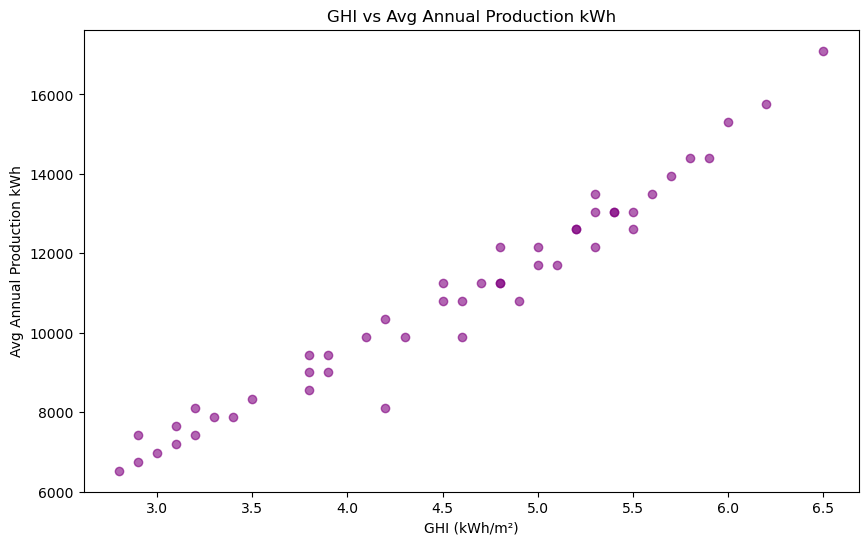

In [61]:
#answer 9: We need to create a scatter plot to visualize the relationship between GHI and Avg Annual Production kWh
plt.figure(figsize=(10, 6))
plt.scatter(df['GHI_kWh_per_m2'], df['Avg_Annual_Production_kWh'], color='purple', alpha=0.6)
plt.title('GHI vs Avg Annual Production kWh')
plt.xlabel('GHI (kWh/m²)')
plt.ylabel('Avg Annual Production kWh')
plt.show()


In [ ]:
#Here we se a linear trend , so we will do a linar regression model to predict Avg Annual Production kWh based on GHI

Mean Squared Error: 381024.6323401812
R^2 Score: 0.8058201111798182
[2627.31405832] -964.4764413002977


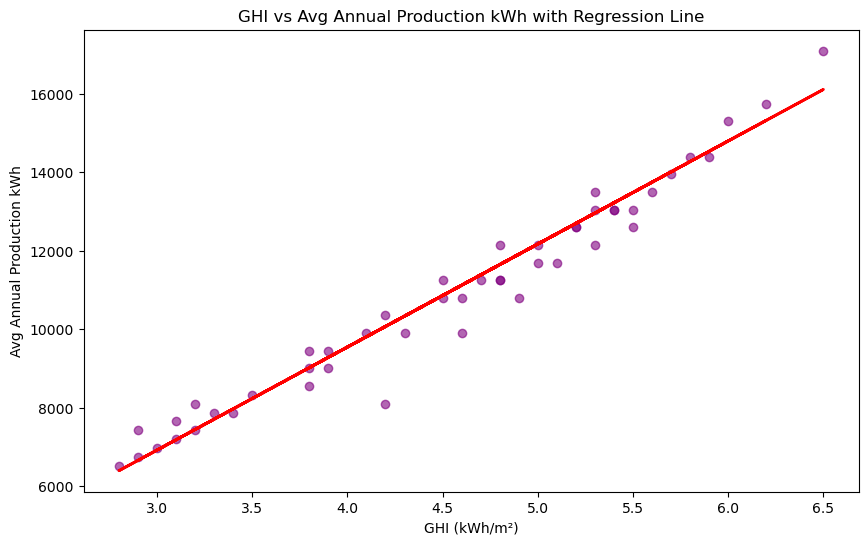

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['GHI_kWh_per_m2']]
y = df['Avg_Annual_Production_kWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
l_model=LinearRegression()
l_model.fit(X_train, y_train)
y_pred=l_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print(l_model.coef_, l_model.intercept_)
#we also need to visualize the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='purple', alpha=0.6)
plt.plot(X, l_model.predict(X), color='red', linewidth=2)
plt.title('GHI vs Avg Annual Production kWh with Regression Line')
plt.xlabel('GHI (kWh/m²)')
plt.ylabel('Avg Annual Production kWh')
plt.show()



11. Correlation of solar viability score with sunlight hours and ROI

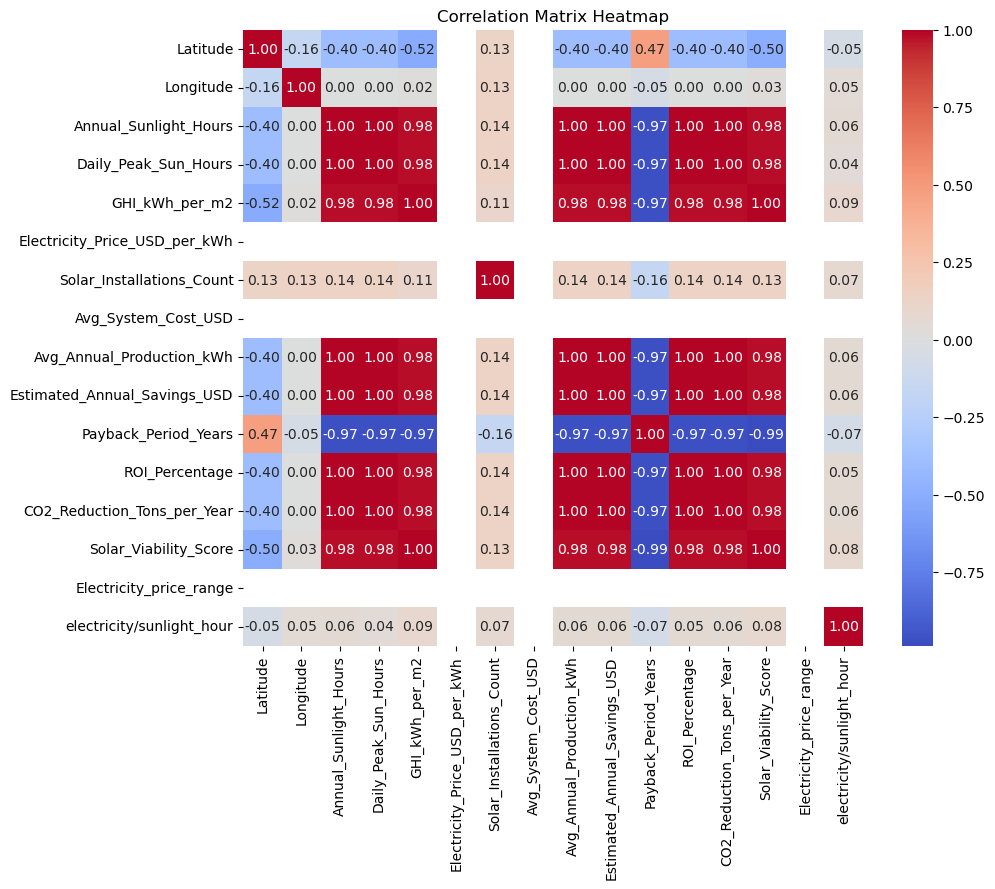

In [ ]:
#answer 11: correlation between columns
correlatable=df.drop(columns=['Country','City','Region'])
correlation_matrix=correlatable.corr()
# we need to visualize the correlation matrix using a heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

The answer is 0.98 and 0.98

## Predictive Analysis
17. Predict ROI using sunlight, cost, electricity price, production.
18. Predict solar viability score using available features.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   City                           48 non-null     object  
 1   Country                        48 non-null     object  
 2   Latitude                       48 non-null     float64 
 3   Longitude                      48 non-null     float64 
 4   Annual_Sunlight_Hours          48 non-null     int64   
 5   Daily_Peak_Sun_Hours           48 non-null     float64 
 6   GHI_kWh_per_m2                 48 non-null     float64 
 7   Electricity_Price_USD_per_kWh  48 non-null     float64 
 8   Solar_Installations_Count      48 non-null     int64   
 9   Avg_System_Cost_USD            48 non-null     int64   
 10  Avg_Annual_Production_kWh      48 non-null     int64   
 11  Estimated_Annual_Savings_USD   48 non-null     float64 
 12  Payback_Period_Years           48 non-

In [71]:


X=df[['Annual_Sunlight_Hours','Solar_Installations_Count','Avg_Annual_Production_kWh']]
y=df['ROI_Percentage']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred=model.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
r2=r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')

#Feature importance
importances=model.feature_importances_
feature_names=X.columns
feature_importance_df=pd.DataFrame({'Feature':feature_names,'Importance':importances})
feature_importance_df=feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

Mean Squared Error: 0.02422730000000025
R^2 Score: 0.9877540942175494
                     Feature  Importance
0      Annual_Sunlight_Hours    0.541149
2  Avg_Annual_Production_kWh    0.452858
1  Solar_Installations_Count    0.005993
